# 🫀 ECG Arrhythmia Classification

**Dataset:** MIT-BIH Arrhythmia Dataset (via Kaggle)  
**Goal:** Classify ECG heartbeats into 5 arrhythmia categories using machine learning  
**Pipeline:** Load → Visualize → Feature Engineering → Train → Evaluate

---

### Class Labels
| Class | Description |
|---|---|
| 0 | Normal (N) |
| 1 | Supraventricular Ectopy (S) |
| 2 | Ventricular Ectopy (V) |
| 3 | Fusion Beat (F) |
| 4 | Unknown (Q) |

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Output directory
os.makedirs('outputs', exist_ok=True)

# Class names for labels
CLASS_NAMES = {
    0: 'Normal (N)',
    1: 'Supraventricular (S)',
    2: 'Ventricular (V)',
    3: 'Fusion (F)',
    4: 'Unknown (Q)'
}

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


## 2. Load Data

In [2]:
# ⚠️ Update path to your local CSV file
df = pd.read_csv(r"C:\Users\berke\OneDrive\Masaüstü\ecg-arrhythmia-classification\mitbih_train.csv", header=None)

# Split features and labels
X = df.iloc[:, :-1].values   # 187 signal values per heartbeat
y = df.iloc[:, -1].values.astype(int)   # class label

print(f'Dataset shape  : {df.shape}')
print(f'Features shape : {X.shape}')
print(f'Classes        : {np.unique(y)}')
print(f'\nClass distribution:')
for cls, name in CLASS_NAMES.items():
    count = np.sum(y == cls)
    pct = count / len(y) * 100
    print(f'  Class {cls} ({name}): {count:,} samples ({pct:.1f}%)')

Dataset shape  : (87554, 188)
Features shape : (87554, 187)
Classes        : [0 1 2 3 4]

Class distribution:
  Class 0 (Normal (N)): 72,471 samples (82.8%)
  Class 1 (Supraventricular (S)): 2,223 samples (2.5%)
  Class 2 (Ventricular (V)): 5,788 samples (6.6%)
  Class 3 (Fusion (F)): 641 samples (0.7%)
  Class 4 (Unknown (Q)): 6,431 samples (7.3%)


## 3. Signal Visualization

Each sample contains 187 time-series values representing one heartbeat cycle.

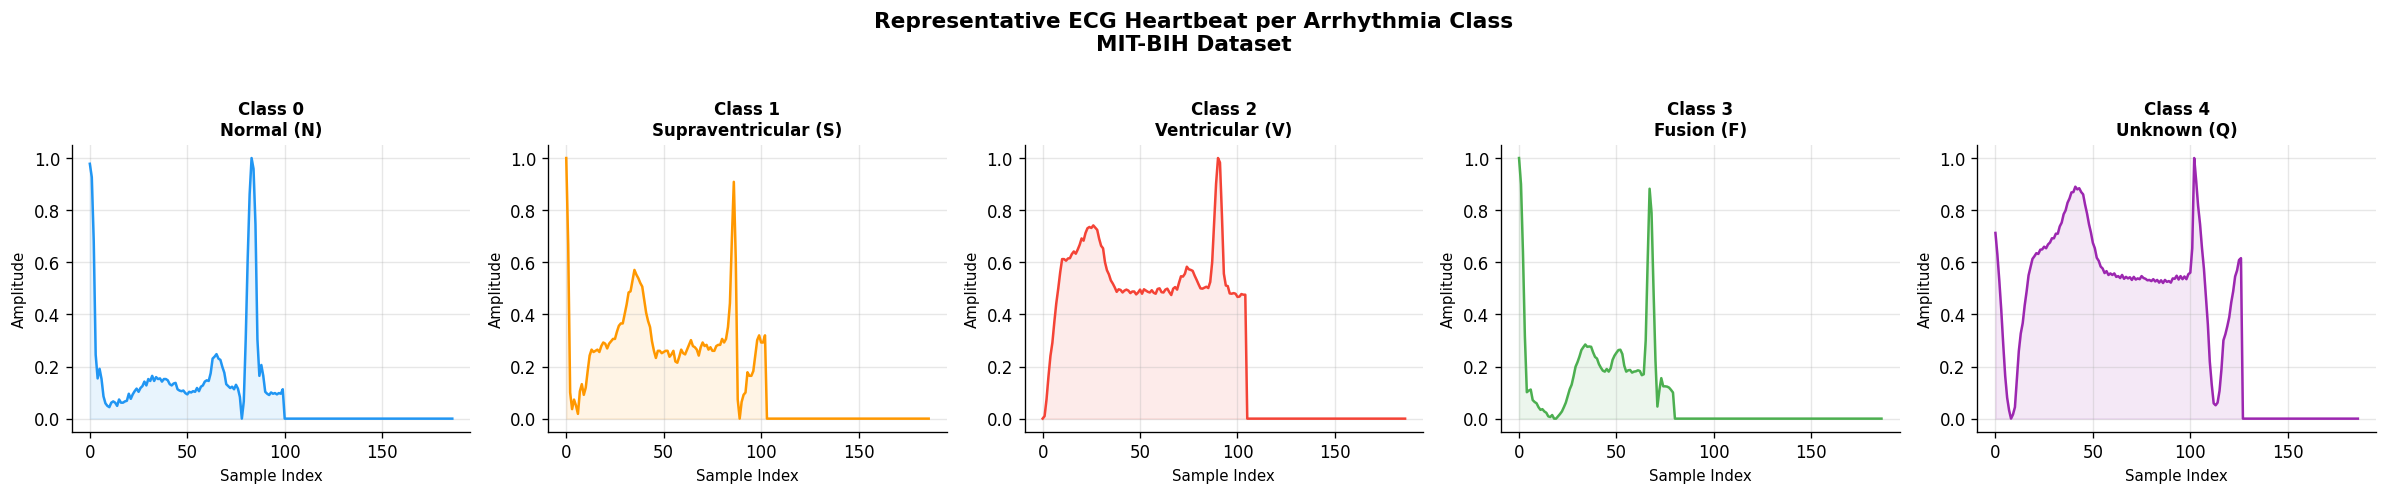

✅ Saved: 01_ecg_classes.png


In [3]:
# Plot one representative heartbeat per class
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colors = ['#2196F3', '#FF9800', '#F44336', '#4CAF50', '#9C27B0']

for idx, (cls, name) in enumerate(CLASS_NAMES.items()):
    sample_idx = np.where(y == cls)[0][0]
    axes[idx].plot(X[sample_idx], color=colors[idx], linewidth=1.5)
    axes[idx].set_title(f'Class {cls}\n{name}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Sample Index', fontsize=9)
    axes[idx].set_ylabel('Amplitude', fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].fill_between(range(187), X[sample_idx], alpha=0.1, color=colors[idx])

plt.suptitle('Representative ECG Heartbeat per Arrhythmia Class\nMIT-BIH Dataset',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/01_ecg_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 01_ecg_classes.png')

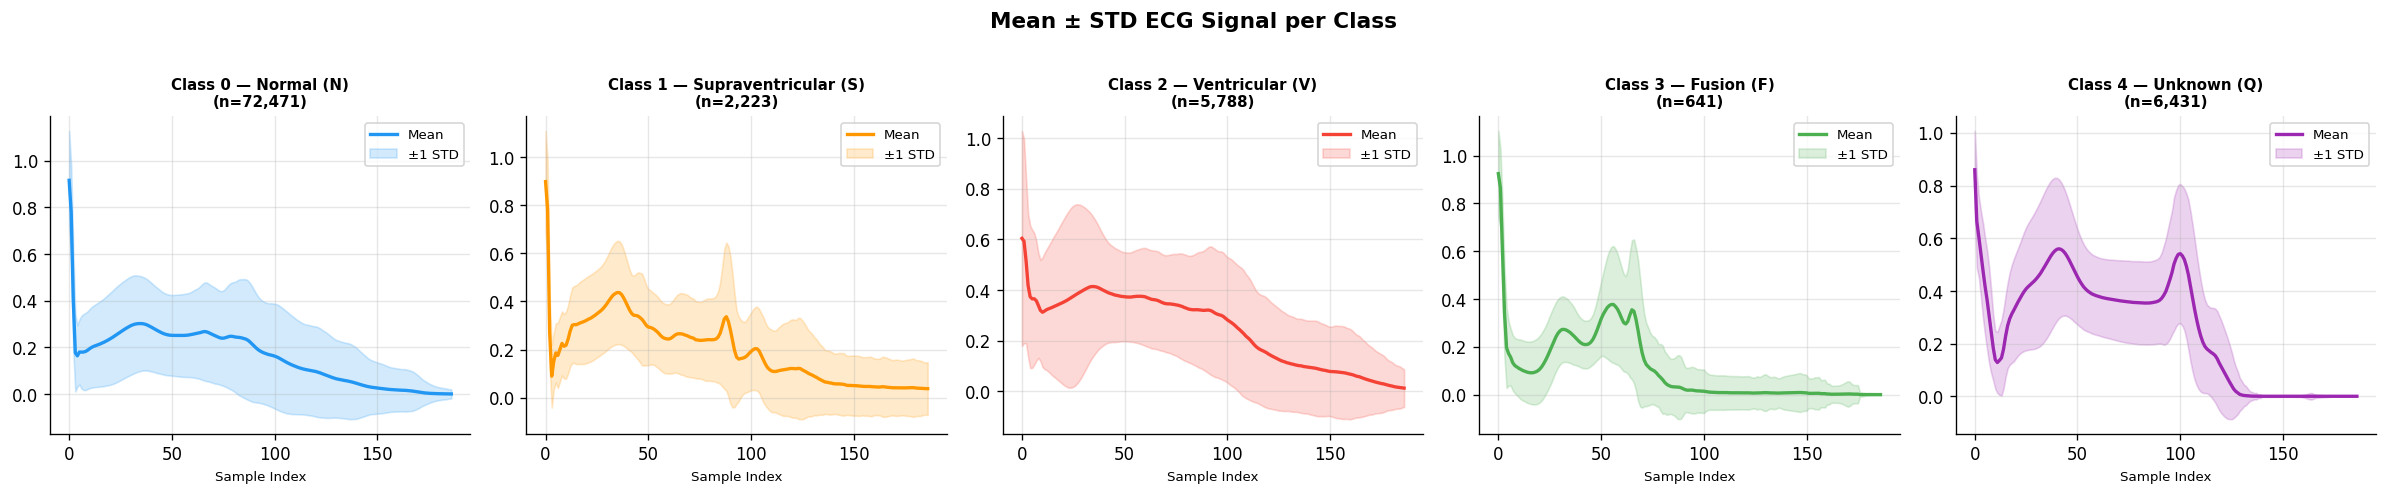

✅ Saved: 02_mean_signals.png


In [4]:
# Average signal per class
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, (cls, name) in enumerate(CLASS_NAMES.items()):
    class_signals = X[y == cls]
    mean_signal = class_signals.mean(axis=0)
    std_signal  = class_signals.std(axis=0)

    axes[idx].plot(mean_signal, color=colors[idx], linewidth=2, label='Mean')
    axes[idx].fill_between(
        range(187),
        mean_signal - std_signal,
        mean_signal + std_signal,
        alpha=0.2, color=colors[idx], label='±1 STD'
    )
    axes[idx].set_title(f'Class {cls} — {name}\n(n={np.sum(y==cls):,})', fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Sample Index', fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=8)

plt.suptitle('Mean ± STD ECG Signal per Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/02_mean_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 02_mean_signals.png')

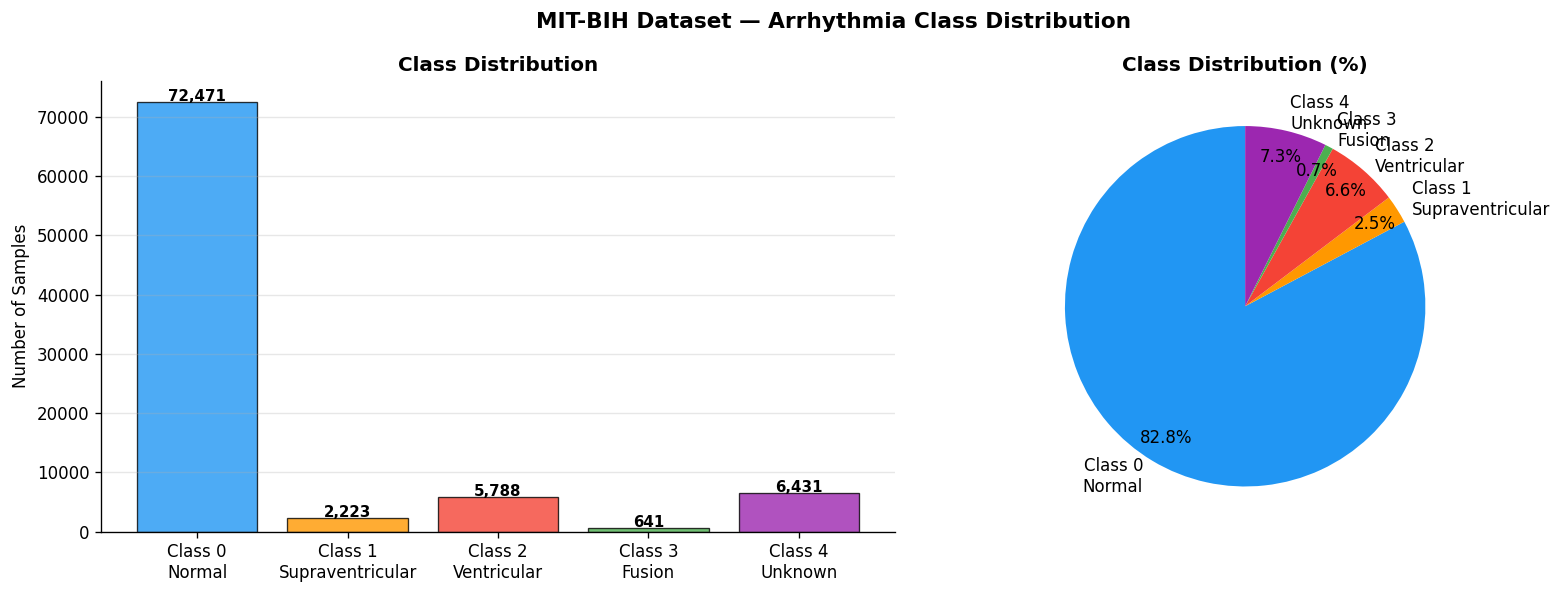

✅ Saved: 03_class_distribution.png


In [5]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = [np.sum(y == cls) for cls in CLASS_NAMES.keys()]
labels = [f'Class {cls}\n{name.split(" ")[0]}' for cls, name in CLASS_NAMES.items()]

# Bar chart
bars = axes[0].bar(labels, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{count:,}', ha='center', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85)
axes[1].set_title('Class Distribution (%)', fontsize=12, fontweight='bold')

plt.suptitle('MIT-BIH Dataset — Arrhythmia Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/03_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 03_class_distribution.png')

## 4. Feature Engineering

We extract statistical and morphological features from each heartbeat signal.
These features will be used as input to the Random Forest classifier.

In [6]:
def extract_features(X):
    """Extract statistical features from raw ECG signals."""
    features = pd.DataFrame()

    # Statistical features
    features['mean']     = X.mean(axis=1)
    features['std']      = X.std(axis=1)
    features['min']      = X.min(axis=1)
    features['max']      = X.max(axis=1)
    features['range']    = X.max(axis=1) - X.min(axis=1)  # amplitude range
    features['median']   = np.median(X, axis=1)
    features['skewness'] = pd.DataFrame(X).skew(axis=1)   # signal asymmetry
    features['kurtosis'] = pd.DataFrame(X).kurt(axis=1)   # peak sharpness

    # Energy feature
    features['energy']   = (X ** 2).sum(axis=1)

    # Peak value and its position
    features['peak_val'] = X.max(axis=1)
    features['peak_pos'] = X.argmax(axis=1)  # where the R-peak occurs

    return features

df_features = extract_features(X)
df_features['label'] = y

print(f'Feature matrix shape: {df_features.shape}')
print(f'Features: {list(df_features.columns[:-1])}')
df_features.head()

Feature matrix shape: (87554, 12)
Features: ['mean', 'std', 'min', 'max', 'range', 'median', 'skewness', 'kurtosis', 'energy', 'peak_val', 'peak_pos']


,mean,std,min,max,range,median,skewness,kurtosis,energy,peak_val,peak_pos,label
0,0.098419,0.176073,0.0,1.0,1.0,0.061275,3.574941,14.029701,7.608654,1.0,83,0
1,0.090010,0.159722,0.0,1.0,1.0,0.054131,3.866087,16.737549,6.285631,1.0,115,0
2,0.062104,0.138769,0.0,1.0,1.0,0.005405,4.359641,22.804009,4.322286,1.0,0,0
3,0.084084,0.160821,0.0,1.0,1.0,0.002762,3.505675,14.097800,6.158557,1.0,80,0
4,0.116567,0.186151,0.0,1.0,1.0,0.056338,3.134928,10.550815,9.020939,1.0,1,0


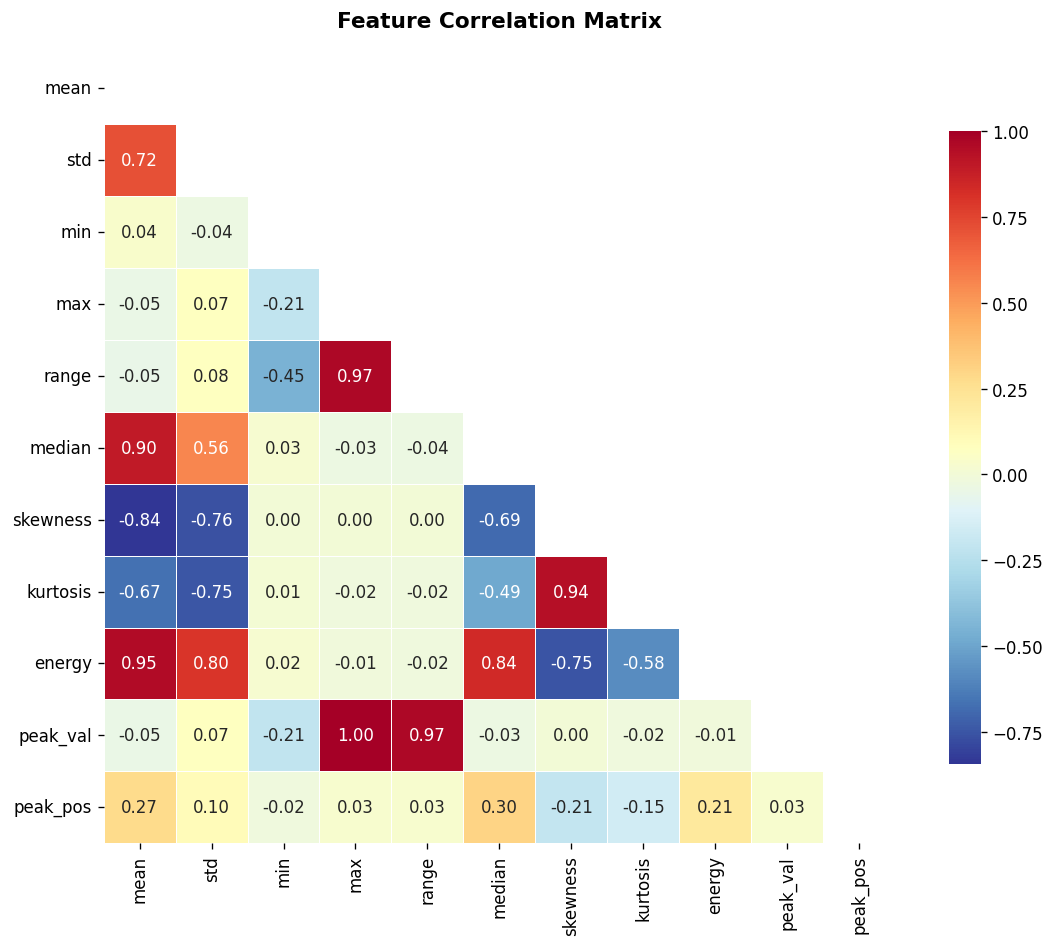

✅ Saved: 04_feature_correlation.png


In [7]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

corr = df_features.drop('label', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            ax=ax, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('outputs/04_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 04_feature_correlation.png')

## 5. Machine Learning — Random Forest Classifier

Random Forest is an ensemble method that builds multiple decision trees and aggregates their predictions.
It handles class imbalance well and provides feature importance scores.

In [8]:
# Prepare data
X_feat = df_features.drop('label', axis=1).values
y_feat = df_features['label'].values

# Train/test split — stratified to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_feat,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y_feat      # preserve class ratios
)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')
print(f'Features used    : {X_train.shape[1]}')

Training samples : 70,043
Test samples     : 17,511
Features used    : 11


In [9]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    max_depth=15,          # limit tree depth to avoid overfitting
    class_weight='balanced',  # handle class imbalance
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'✅ Model trained successfully!')
print(f'Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)')

✅ Model trained successfully!
Overall Accuracy: 0.8717 (87.17%)


## 6. Evaluation

In [10]:
# Classification report
target_names = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]
print('Classification Report:')
print('=' * 70)
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
                      precision    recall  f1-score   support

          Normal (N)       0.96      0.90      0.93     14494
Supraventricular (S)       0.28      0.58      0.38       445
     Ventricular (V)       0.74      0.68      0.71      1158
          Fusion (F)       0.24      0.73      0.36       128
         Unknown (Q)       0.71      0.85      0.77      1286

            accuracy                           0.87     17511
           macro avg       0.59      0.75      0.63     17511
        weighted avg       0.90      0.87      0.88     17511



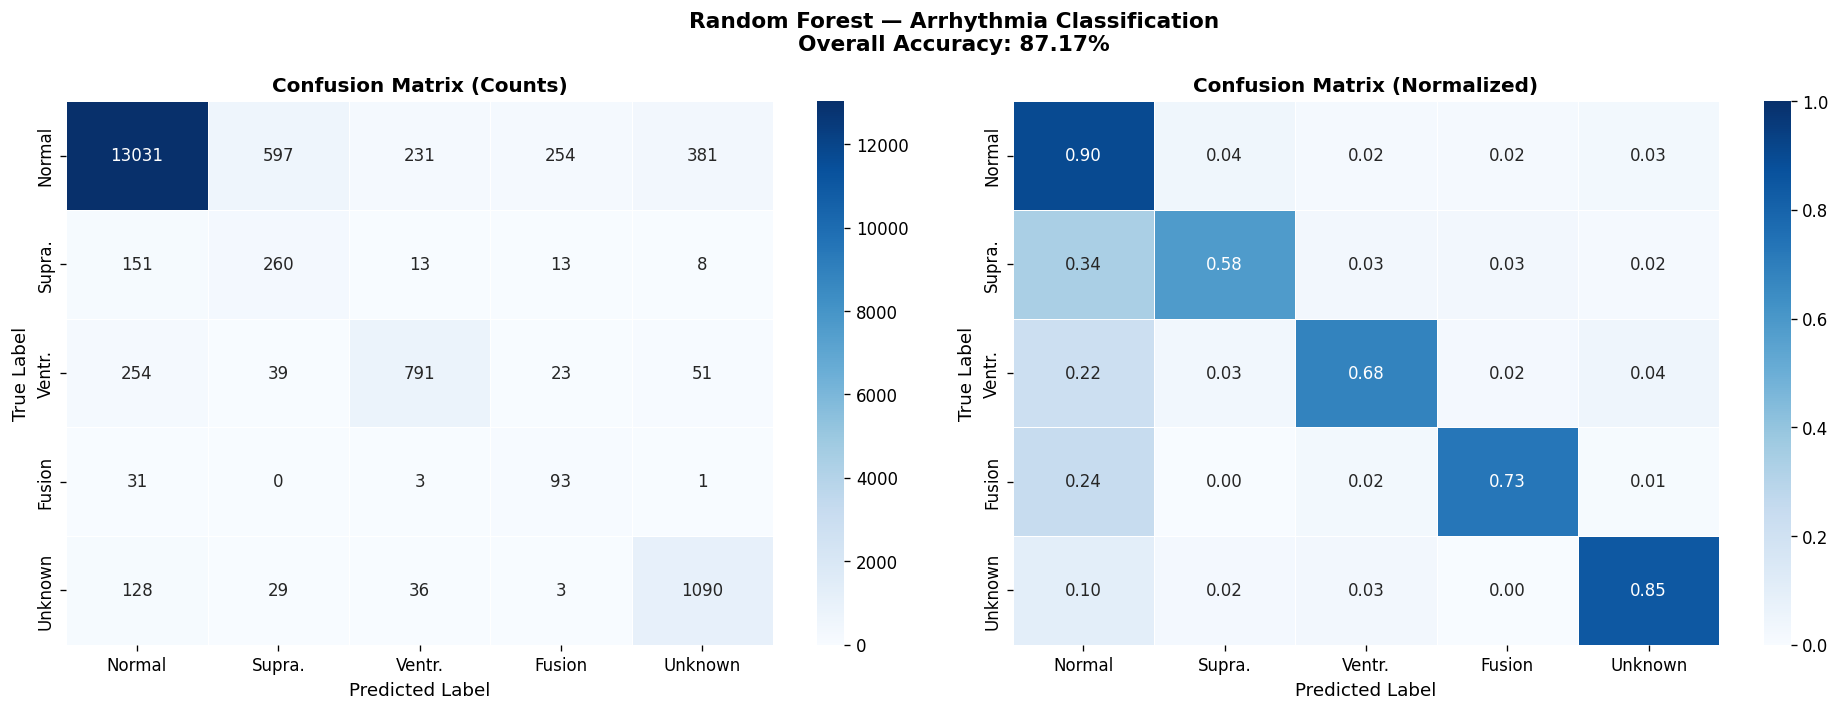

✅ Saved: 05_confusion_matrix.png


In [11]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
short_names = ['Normal', 'Supra.', 'Ventr.', 'Fusion', 'Unknown']

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.suptitle(f'Random Forest — Arrhythmia Classification\nOverall Accuracy: {acc*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 05_confusion_matrix.png')

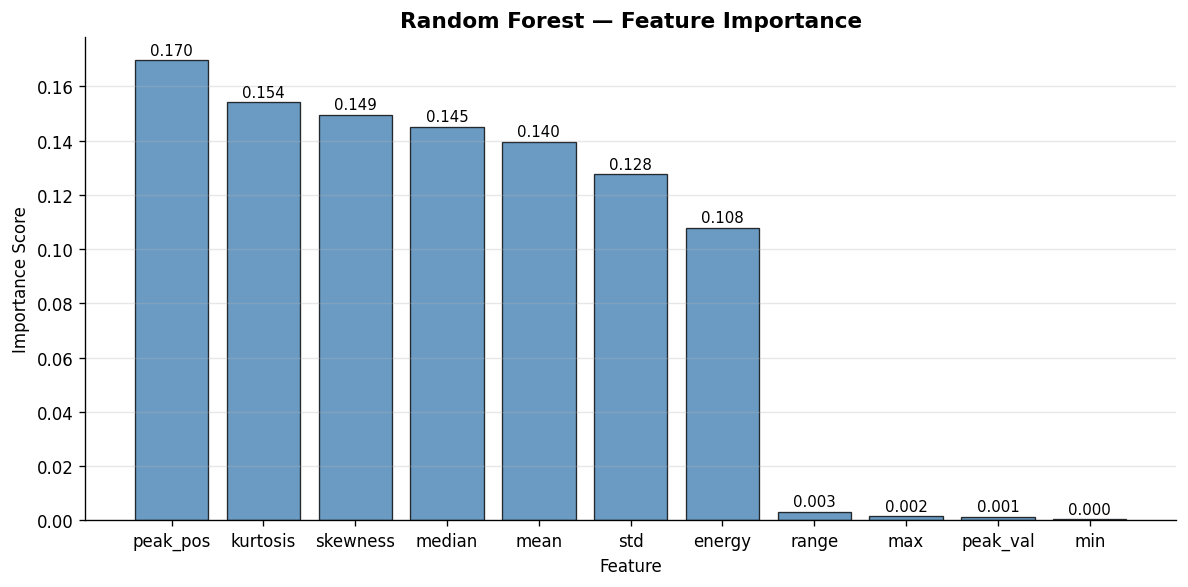

✅ Saved: 06_feature_importance.png


In [12]:
# Feature importance
feature_names = list(df_features.columns[:-1])
importances   = rf.feature_importances_
sorted_idx    = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [feature_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.8
)
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance Score')
ax.set_xlabel('Feature')
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 06_feature_importance.png')

## 7. Summary

This notebook implemented a complete ECG arrhythmia classification pipeline:

1. **Data Loading:** MIT-BIH dataset with 87,554 heartbeat samples across 5 classes
2. **Visualization:** Per-class signal plots with mean ± STD shading
3. **Feature Engineering:** 10 statistical/morphological features per heartbeat
4. **Classification:** Random Forest with 100 estimators, balanced class weights
5. **Evaluation:** Confusion matrix, per-class precision/recall/F1

**Key finding:** The model achieves strong performance on Normal (Class 0) beats due to class dominance (~83% of data). Per-class metrics reveal the challenge of classifying rare arrhythmia types — a common clinical challenge in automated ECG interpretation.

---
*Dataset: MIT-BIH Arrhythmia Database — Moody & Mark (2001)*